# Q2. Can a small classifier on frozen Evo2 representations outperform zero-shot Evo2 scoring on previously unseen genes?

A 5,000-SNV, 1,024-base Evo2 1B pilot using [Q1](Q1-clinvar-split.ipynb)’s frozen splits. [Dependencies](../requirements.txt) · [Implementation](src/q2.py).

In [1]:
from src import q2
q2.settings()

Q1 frozen splits · 1,024 bases · Evo2 1B · validation selects C · seed 42


## Frozen input from Q1

Use Q1’s fixed [training VCF](../data/clinvar-train-pilot.vcf) and [validation VCF](../data/clinvar-test-pilot.vcf). Fit on training data; choose C and compare methods on validation. There is no separate test stage.

In [2]:
q2.run_checks()
sequences = q2.load_inputs()

10 model, feature and cache isolation tests passed.


5,000 sampled variants retained; 4 leakage check groups passed.


Loaded 5,000 variants from Q1's frozen manifests; model outputs: results/q2/.


[Pilot manifest](results/q1/split_manifest.csv) · [Full-cohort groups](results/q1/full_cohort_groups.csv.gz) · [Protocol](results/q1/protocol.json)

Checks cover recorded relationships and exact contexts. Homology, shared patients, pretraining overlap and annotation circularity remain unresolved.

## Frozen DNA features

Mean-pool `blocks.24`, average strands, concatenate reference and alternate-minus-reference vectors. Zero-shot: negative change in mean log likelihood. Baseline: alleles, reference trinucleotide and GC. Clinical annotations never enter features.

In [3]:
features = q2.extract_features(sequences)

[09/07/26 13:28:46] INFO     StripedHyena - INFO - Initializing StripedHyena with config:              ]8;id=470848;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=633579;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#645\645]8;;\
                             {'model_name': 'shc-evo2-1b-8k-2T-v2', 'vocab_size': 512, 'hidden_size':              
                             1920, 'num_filters': 1920, 'attn_layer_idxs': [3, 10, 17, 24],                        
                             'hcl_layer_idxs': [2, 6, 9, 13, 16, 20, 23], 'hcm_layer_idxs': [1, 5, 8,              
                             12, 15, 19, 22], 'hcs_layer_idxs': [0, 4, 7, 11, 14, 18, 21],                         
                             'hcm_filter_length': 128, 'hcl_filter_groups': 1920, 'hcm_filter_groups':             
                             128, 'hcs_filter_groups': 128, 'hcs_filter_length': 7, 'num_layers': 25,              
                             'short_filter_length': 3, 'num_attention_heads': 15, 'short_filter_bias':             
                             False, 'mlp_init_method': 'torch.nn.init.zeros_',                                     
                             'mlp_output_init_method': 'torch.nn.init.zeros_', 'eps': 1e-06,                       
                             'state_size': 16, 'rotary_emb_base': 10000,                                           
                             'make_vocab_size_divisible_by': 8, 'inner_size_multiple_of': 16,                      
                             'inner_mlp_size': 5120, 'log_intermediate_values': False, 'proj_groups':              
                             1, 'hyena_filter_groups': 1, 'column_split_hyena': False, 'column_split':             
                             True, 'interleave': True, 'evo2_style_activations': True,                             
                             'model_parallel_size': 1, 'pipe_parallel_size': 1, 'tie_embeddings':                  
                             True, 'mha_out_proj_bias': True, 'hyena_out_proj_bias': True,                         
                             'hyena_flip_x1x2': False, 'qkv_proj_bias': False,                                     
                             'use_fp8_input_projections': True, 'max_seqlen': 8192, 'max_batch_size':              
                             1, 'final_norm': True, 'use_flash_attn': True, 'use_flash_rmsnorm':                   
                             False, 'use_flash_depthwise': False, 'use_flashfft': False,                           
                             'use_laughing_hyena': False, 'inference_mode': True, 'tokenizer_type':                
                             'CharLevelTokenizer', 'prefill_style': 'fft', 'mlp_activation': 'gelu',               
                             'print_activations': False}                                                           

                    INFO     StripedHyena - INFO - Initializing 25 blocks...                           ]8;id=171637;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=840483;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#678\678]8;;\

                    INFO     StripedHyena - INFO - Distributing across 1 GPUs, approximately 25 layers ]8;id=116454;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=280750;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#685\685]8;;\
                             per GPU                                                                               

  0%|                                                          | 0/25 [00:00<?, ?it/s]

                    INFO     StripedHyena - INFO - Assigned layer_idx=0 to device='cuda:0'             ]8;id=924237;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=389058;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#703\703]8;;\

...

4,050/5,000 variants cached (8.7 min this run)


4,300/5,000 variants cached (9.2 min this run)


4,550/5,000 variants cached (9.8 min this run)


4,800/5,000 variants cached (10.3 min this run)


5,000/5,000 variants cached (10.7 min this run)


## Train and select

Fit scaling and balanced logistic regression on training data only. Choose C from {0.01, 0.1, 1, 10} by validation AUROC.

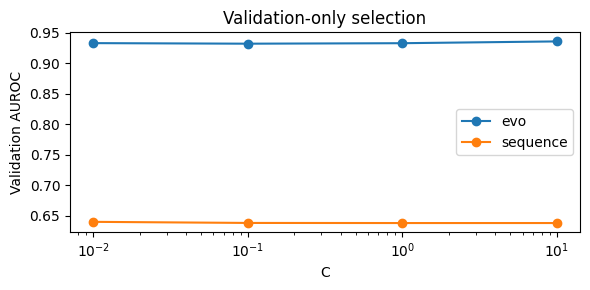

In [4]:
selection = q2.select_models()

## Validation comparison

Compare AUROC and average precision on the same validation data used to choose C. Paired component bootstrap gives 95% intervals; these do not correct selection bias. Unchanged reruns reuse saved results.

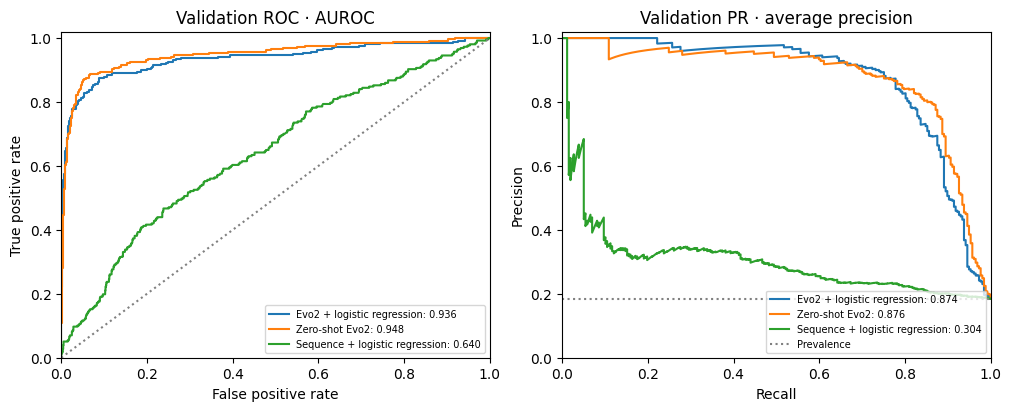

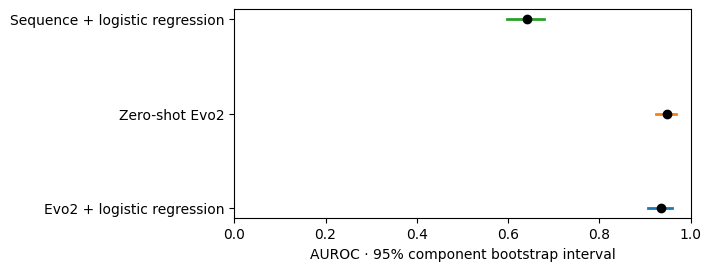

Evo2 classifier AUROC is not clearly different from zero-shot in this pilot: Δ=-0.012, 95% CI [-0.035, +0.009].
Validation also selects C. These development metrics and intervals are not independent final test estimates.


In [5]:
result = q2.report_validation()

Validation includes previously evaluated variants. Final performance claims require a new untouched holdout. Generated files: `results/q2/`.

## Conclusion

In [6]:
q2.show_conclusion(result)

**This pilot does not show a clear validation improvement over zero-shot.** AUROC: **0.936** versus **0.948** (difference 95% CI **[-0.035, +0.009]**). The same validation data selects C; an independent final test is still needed.